In [17]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [18]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [19]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497

In [20]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
# quantum_band = r'kp8'
# quantum_band_interactions = r'kp8_kp8'

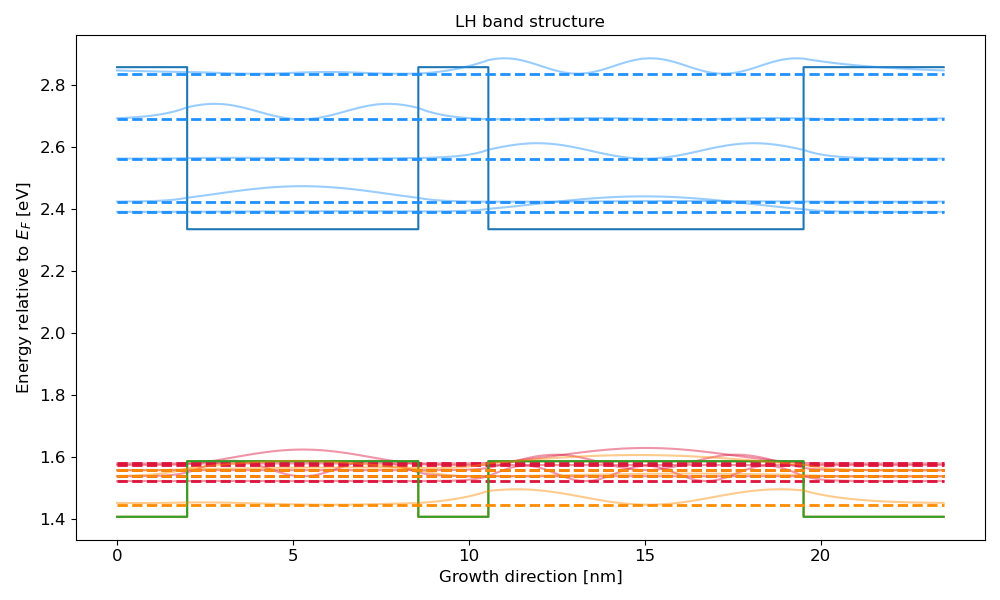

[]

In [21]:
%matplotlib widget
parent_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\InGaAs_InAlAs_DW_singleband_or_kp8(5)'
model = '1band'
simoutidk = build_output(parent_dir, quantum_region, bias, 14, model=model)

# simoutidk = build_output(parent_dir, quantum_region, bias, 14, model=model,VB_cutoff=0.25,quantum_band=quantum_band, quantum_band_interactions=quantum_band_interactions)
# simoutidk.bands['CB'].sort_subbands(decreasing=False)
# simoutidk.bands['VB'].sort_subbands(decreasing=True)
simoutidk.bands['Gamma'].sort_subbands(decreasing=False)
# simoutidk.bands['CB'].remove_subband(index=7)
# simoutidk.bands['CB'].remove_subband(index=6)
simoutidk.bands['HH'].sort_subbands(decreasing=True)
simoutidk.bands['LH'].sort_subbands(decreasing=True)

barrier_len = simoutidk.variables['w_barrier']
well_len = simoutidk.variables['w_well']
temp = simoutidk.variables['temp']

dop_cc = simoutidk.variables['impurity_conc_cc']
# Al_x = simoutidk.variables['Al_alloy']
Al_alloy = simoutidk.variables['Al_alloy']
In_alloy = simoutidk.variables['In_alloy']
Eact_C_InAlAs = simoutidk.variables['Eact_C_InAlAs']
Eact_C_InGaAs = simoutidk.variables['Eact_C_InGaAs']

title_base = f"barrier={barrier_len}nm, well={well_len}nm, temp={temp}K, dop_cc={dop_cc:.2e}cm^-3, \n $Al_x$={Al_alloy:.2f}, $In_x$={In_alloy:.2f}, Eact_C_InAlAs={Eact_C_InAlAs:.2f}eV, Eact_C_InGaAs={Eact_C_InGaAs:.2f}eV, model={model}"
# all_band_fig,all_band_ax = plt.subplots()
PMI_fig, PMI_ax = simoutidk.plot_all_bands(title_diff=title_base,fontsizebase=12,fontsizetitle=12,add_title=False,add_legend=False)
PMI_ax.set_xticks([])
PMI_ax.set_yticks([])
# VB_fig,VB_ax = plt.subplots()
# simoutidk.bands['VB'].plot_band(ax=VB_ax,title_diff=title_base+' VB only', normalize_y=False,show=True,fontsizetitle=12,fontsizebase=12)
# simoutidk.bands['HH'].plot_band(ax=VB_ax,title_diff=title_base+' HH only', normalize_y=False,show=False,fontsizetitle=12,fontsizebase=12)

# simoutidk.bands['LH'].plot_band(ax=VB_ax,title_diff=title_base+' HH and LH', normalize_y=False,show=True,fontsizetitle=12,fontsizebase=12)


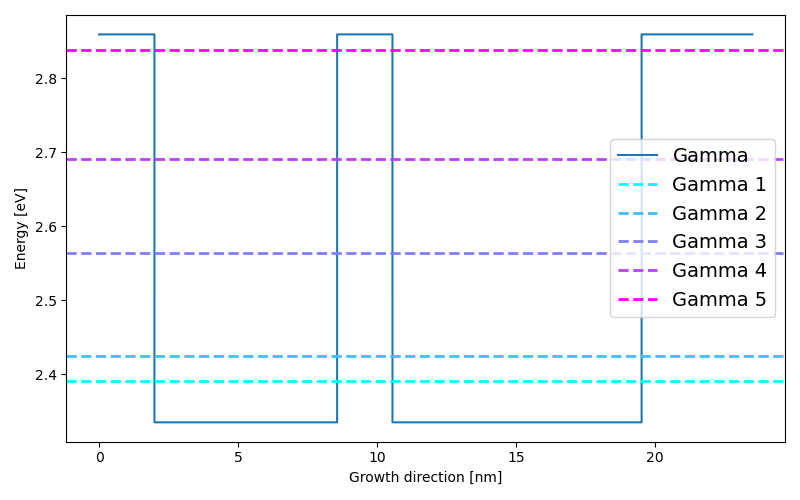

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

# band edges
for edge in simoutidk.bands['Gamma'].bandedges:
    ax.plot(edge.x, edge.energy, label=edge.name)

# energy levels only
n = len(simoutidk.bands['Gamma'].subbands)
cmap = plt.colormaps['cool']
for subband in sorted(simoutidk.bands['Gamma'].subbands, key=lambda s: s.energy):
    rank = sorted([s.energy for s in simoutidk.bands['Gamma'].subbands]).index(subband.energy)
    c = cmap(rank / max(n - 1, 1))
    ax.axhline(subband.energy, ls='--', color=c, lw=2.0, label=f'Gamma {subband.index}')

ax.set_xlabel("Growth direction [nm]")
ax.set_ylabel("Energy [eV]")
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()


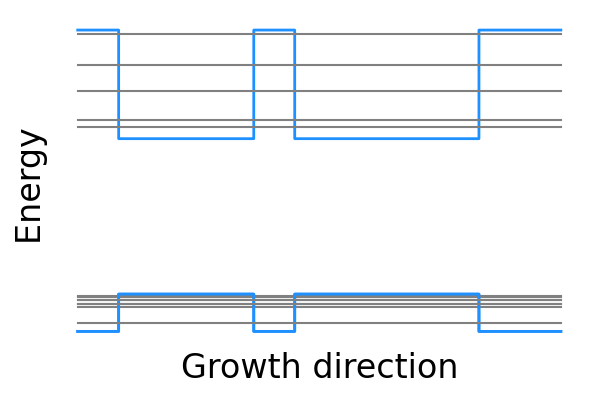

In [38]:
band_colors = {'CB': 'dodgerblue', 'VB': 'crimson',
               'Gamma': 'gray', 'HH': 'gray', 'LH': 'gray'}

fig, ax = plt.subplots(figsize=(6, 4))
base_font = 24
x_energies = simoutidk.bands['Gamma'].x 

for name, band in simoutidk.bands.items():
    color = band_colors.get(name, 'gray')
    for edge in band.bandedges:
        ax.plot(edge.x, edge.energy, color='dodgerblue', lw=2)
    for subband in band.subbands:
        energy_ones = np.ones_like(x_energies) * subband.energy
        ax.plot(x_energies, energy_ones, color=color, lw=1.5)

ax.set_xlabel("Growth direction", fontsize=base_font)
ax.set_ylabel("Energy ", fontsize=base_font)
# ax.legend(fontsize=13)
# ax.tick_params(labelsize=base_font)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
plt.tight_layout()
plt.show()
